# Test the definition of a binarized 3AFC linear ballistic accumulator model

This model groups choices into a correct choice (accumulator 1) and incorrect choices (accumulators 2 and 3).

In [1]:
import os
import numpy as np
from scipy import integrate
import pandas as pd
import seaborn as sns
from devreact import model
from devreact import figures

figures.set_style()

## Generate data

In [2]:
rng = np.random.default_rng()
nt = 10000
s = 1
τ = 0.5
A = 4
b = 5
v1 = 3
v2 = 1.5
response = model.random(s, τ, A, b, v1, v2, rng, size=(nt, 2))

## Evaluate PDF

In [3]:
# set times and responses to evaluate
n = 100  # number of times
m = 2  # number of choices
max_time = 4
t = np.tile(np.linspace(0, max_time, n), m)
r = np.repeat(range(m), n).astype('int32')
f = model.function_pdf()
sweep = pd.DataFrame(
    {
        'response': r,
        'response_time': t,
        'pdf': np.zeros(n * m),
    }
)
rmat = sweep[['response', 'response_time']].to_numpy().astype('float64')
sweep['pdf'] = f(rmat, s, τ, A, b, v1, v2)

In [4]:
subs = sweep.query('response == 0')
integrate.trapz(subs['pdf'], subs['response_time'])

0.3540125627429936

In [5]:
subs = sweep.query('response == 1')
integrate.trapz(subs['pdf'], subs['response_time'])

0.6444542591447364

In [6]:
integrate.trapz(sweep['pdf'], sweep['response_time'])

0.9965909213624601

## Compare generated data to PDF

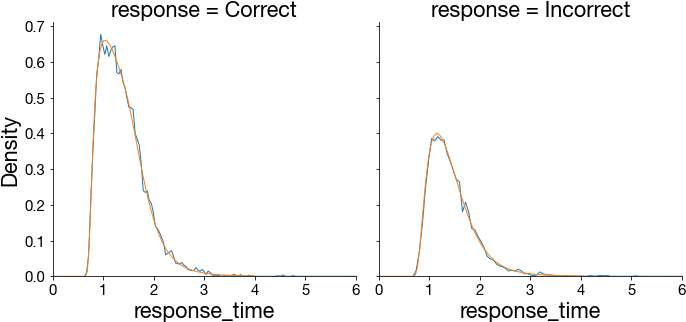

In [7]:
sim = pd.DataFrame({'response': response[:, 0], 'response_time': response[:, 1]})
sim['response'] = sim['response'].map({0: 'Incorrect', 1: 'Correct'})
g = sns.displot(
    data=sim,
    x='response_time',
    col='response',
    kind='kde',
    bw_adjust=.2,
    col_order=['Correct', 'Incorrect'],
)
g.set(xlim=(0, 6))

sns.lineplot(
    data=sweep.query('response == 1'),
    x='response_time',
    y='pdf',
    color='C1',
    ax=g.axes[0, 0],
)
sns.lineplot(
    data=sweep.query('response == 0'),
    x='response_time',
    y='pdf',
    color='C1',
    ax=g.axes[0, 1],
);

In [8]:
%load_ext watermark
%watermark -v -iv

Python implementation: CPython
Python version       : 3.10.4
IPython version      : 8.3.0

seaborn : 0.11.2
pandas  : 1.4.2
scipy   : 1.7.3
devreact: 0.1.0
numpy   : 1.22.1

